# Heart Disease Prediction using Multiple Machine Learning Models

In this project, I trained multiple ML models to predict whether a person has heart disease based on clinical features. I compared different algorithms, evaluated accuracy and recall, plotted ROC curve, tuned hyperparameters using GridSearchCV, and finally saved the best model.

In [ ]:
import pandas as pd
import numpy as np 

In [ ]:
df = pd.read_csv("heart.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [ ]:
X = df.drop("target",axis=1)
y = df["target"]

In [ ]:
from sklearn.model_selection import train_test_split

40% data for testing, 60% for training.

In [ ]:
X_train , X_test, y_train, y_test = train_test_split(X,y, test_size=0.4, random_state=42)

Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
forest = RandomForestClassifier()
forest.fit(X_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Gaussian Naive Bayes

In [ ]:
from sklearn.naive_bayes import GaussianNB
gsn = GaussianNB()
gsn.fit(X_train,y_train)

,priors,None
,var_smoothing,1e-09


Gradient Boosting

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
boosting = GradientBoostingClassifier()
boosting.fit(X_train,y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


# Scaling Data

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

KNN

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()
knn.fit(X_train_scaled,y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
lgr= LogisticRegression()
lgr.fit(X_train_scaled,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


Support Vector Machine

In [ ]:
from sklearn.svm import SVC
svm = SVC()
svm.fit(X_train_scaled,y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


I trained 7 machine learning models on the same dataset to compare their performance.

Checking Model Accuracy

In [ ]:
forest.score(X_test,y_test) #RandomForestClassifier

0.9853658536585366

In [ ]:
gsn.score(X_test,y_test) #GaussianNB

0.8146341463414634

In [ ]:
boosting.score(X_test,y_test) #GradientBoostingClassifier

0.9609756097560975

In [ ]:
knn.score(X_test_scaled,y_test) #knn

0.8634146341463415

In [ ]:
lgr.score(X_test_scaled,y_test) #LogisticRegression

0.8170731707317073

In [ ]:
svm.score(X_test_scaled,y_test) #svm

0.9243902439024391

I evaluated accuracy of all models.

In [ ]:
from sklearn.metrics import recall_score

# Checking Recall Score (Important for medical datasets)

In [ ]:
y_pred = forest.predict(X_test)
print("forest", recall_score(y_test,y_pred))

forest 0.9711538461538461


In [ ]:
y_pred = gsn.predict(X_test)
print("GaussianNB", recall_score(y_test,y_pred))

GaussianNB 0.8605769230769231


In [ ]:
y_pred = boosting.predict(X_test)
print("GradientBoostingClassifier", recall_score(y_test,y_pred))

GradientBoostingClassifier 0.9663461538461539


In [ ]:

y_pred = knn.predict(X_test_scaled)
print("knn", recall_score(y_test,y_pred))

knn 0.8942307692307693


In [ ]:
y_pred = lgr.predict(X_test_scaled)
print("logistic regression", recall_score(y_test,y_pred))

logistic regression 0.8701923076923077


In [ ]:
y_pred = svm.predict(X_test_scaled)
print("svm", recall_score(y_test,y_pred))

svm 0.9567307692307693


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score,roc_curve

I plotted the ROC Curve to evaluate model performance based on sensitivity and false positive rate.

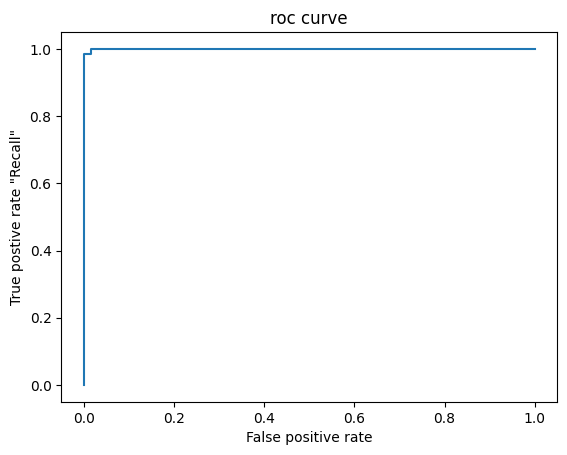

In [ ]:
y_probs = forest.predict_proba(X_test)[:,1]
fpr, tpr ,thresholds = roc_curve(y_test,y_probs)
plt.plot(fpr,tpr)
plt.xlabel('False positive rate')
plt.ylabel('True postive rate "Recall"')
plt.title ('roc curve')
plt.show()

In [ ]:
roc_auc_score(y_test,y_probs)

0.999785795887281

# Hyperparameter Tuning (GridSearchCV)

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 500],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2', None] 
}

forest = RandomForestClassifier(n_jobs=-1, random_state=42)
gridSearch = GridSearchCV(forest, param_grid, cv=3, n_jobs=-1)

I used GridSearchCV to find the best parameters for Random Forest.
This improved accuracy and model performance.

In [ ]:
gridSearch.fit(X_train, y_train)

,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [None, 10, ...], 'max_features': ['sqrt', 'log2', ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [100, 200, ...]}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [ ]:
best_forest = gridSearch.best_estimator_

In [ ]:
best_forest.score(X_test,y_test)

0.9853658536585366

<Axes: >

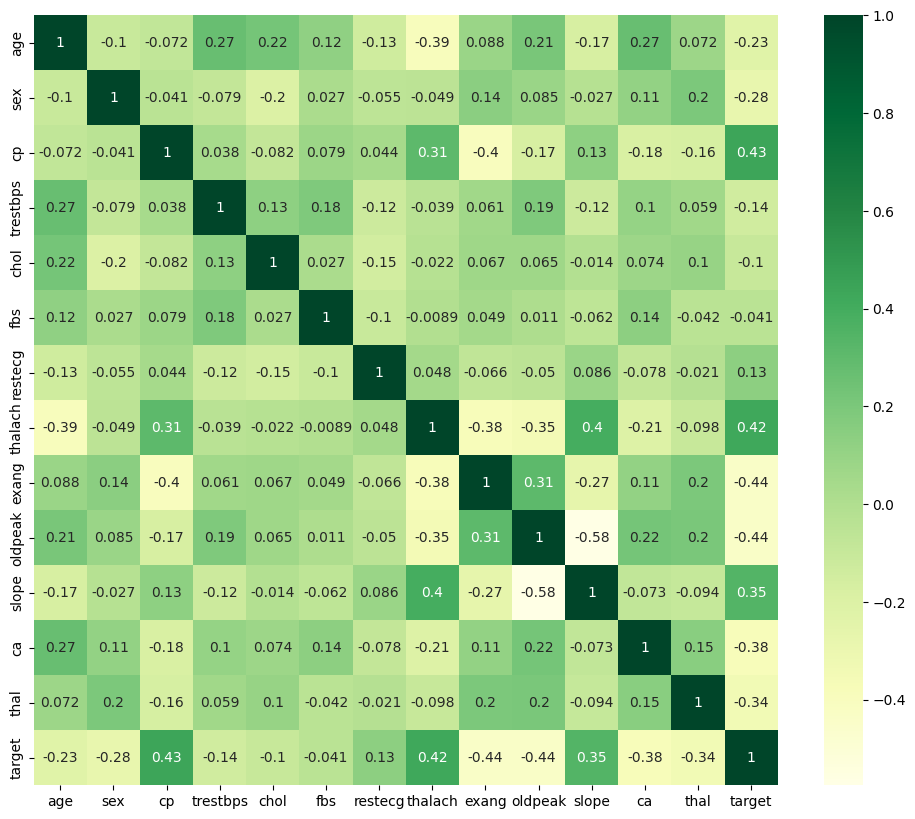

In [ ]:
import seaborn as sns

plt.figure(figsize=(12,10))
sns.heatmap(df.corr(),annot=True,cmap='YlGn')

I visualized feature correlations to understand which features impact heart disease.

In [ ]:
import joblib


joblib.dump(best_forest, 'random_forest_model.pkl')



['random_forest_model.pkl']

I built a Heart Disease Prediction model by training 7 machine learning algorithms and comparing their accuracy and recall. I also plotted the ROC curve, performed hyperparameter tuning using GridSearchCV, and saved the best Random Forest model as a .pkl file.”